In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import textalloc as ta
from scipy.cluster.hierarchy import dendrogram, leaves_list, linkage, optimal_leaf_ordering
from sklearn import set_config
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import pairwise_distances

set_config(transform_output="pandas")

In [2]:
tips_matrix = pd.read_csv("02_tips_matrix.csv", index_col="player_id")
tips_matrix.columns.name = "tip_id"

player_lookup = pd.read_csv("02_player_lookup.csv", index_col="player_id")

In [3]:
tips_matrix_z_scores = (tips_matrix - tips_matrix.mean()) / tips_matrix.std()

In [4]:
stats = tips_matrix.std().rename("std deviation").to_frame()

value_counts = tips_matrix.apply(pd.Series.value_counts)
value_counts_norm = value_counts / value_counts.sum()

stats["entropy (bits)"] = (-value_counts_norm * np.log2(value_counts_norm)).sum()
stats["exp2(entropy)"] = np.exp2(stats["entropy (bits)"])

stats["bracket_tip"] = stats.index.str.startswith("BRACKET").astype(int)

stats.to_csv("03_stats.csv")

In [5]:
thingo = tips_matrix_z_scores.stack().rename("z_score").to_frame()
thingo["orig_tip_val"] = tips_matrix.stack()
thingo = thingo.dropna(subset="orig_tip_val").fillna(0).reset_index()

thingo["bracket_tip"] = thingo["tip_id"].str.startswith("BRACKET")

thingo["tip"] = "away"
thingo.loc[thingo["orig_tip_val"] == 0, "tip"] = "draw"
thingo.loc[thingo["orig_tip_val"] == 1, "tip"] = "home"
thingo.loc[thingo["orig_tip_val"] == 0.42, "tip"] = "group"
thingo.loc[(thingo["orig_tip_val"] == 1) & thingo["bracket_tip"], "tip"] = "r32"
thingo.loc[thingo["orig_tip_val"] == 2, "tip"] = "r16"
thingo.loc[thingo["orig_tip_val"] == 3, "tip"] = "quarter"
thingo.loc[thingo["orig_tip_val"] == 4, "tip"] = "semi"
thingo.loc[thingo["orig_tip_val"] == 4.42, "tip"] = "third"
thingo.loc[thingo["orig_tip_val"] == 5, "tip"] = "final"
thingo.loc[thingo["orig_tip_val"] == 6, "tip"] = "winner"

thingo["name"] = thingo["player_id"].map(player_lookup["safe_name"])

tip_bravery = (
    thingo.groupby(["tip_id", "tip", "z_score"])
    .agg(
        num_tippers=("name", "count"),
        tippers=("name", sorted),
    )
    .reset_index()
    .sort_values("tip_id")
    .sort_values(
        ["z_score", "tip_id"], key=lambda col: col.abs() if col.name == "z_score" else col, ascending=[False, True]
    )
)

tip_bravery.to_csv("03_tip_bravery.csv", index=False)

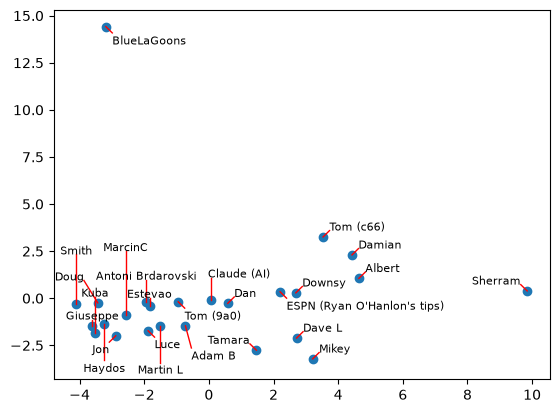

In [6]:
tips_matrix_z_score_imputed = tips_matrix_z_scores.fillna(0)  # impute missing tips as the mean
tips_matrix_z_score_imputed.index = tips_matrix_z_score_imputed.index.map(player_lookup["safe_name"])
tips_matrix_z_score_imputed.index.name = "name"

pca = PCA(n_components=0.5)
pca.fit(tips_matrix_z_score_imputed)

transformed = pca.transform(tips_matrix_z_score_imputed)

fig, ax = plt.subplots()
scattered = ax.scatter(list(transformed["pca0"]), list(transformed["pca1"]))
ta.allocate(
    ax,
    list(transformed["pca0"]),
    list(transformed["pca1"]),
    list(transformed.index),
    x_scatter=list(transformed["pca0"]),
    y_scatter=list(transformed["pca1"]),
    textsize=8,
)
plt.show()

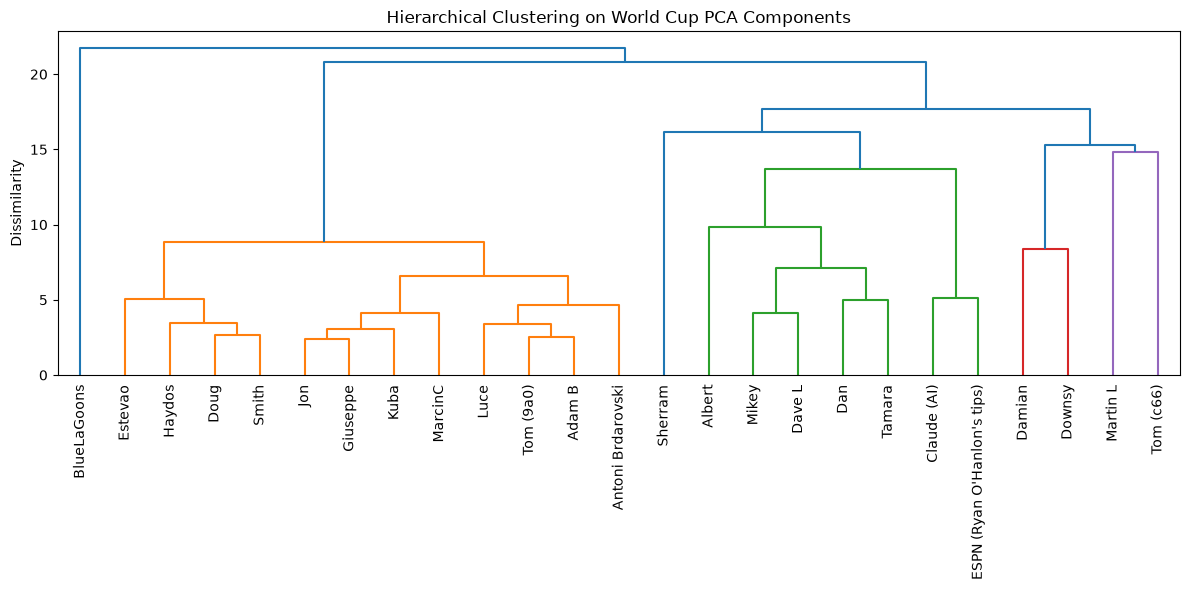

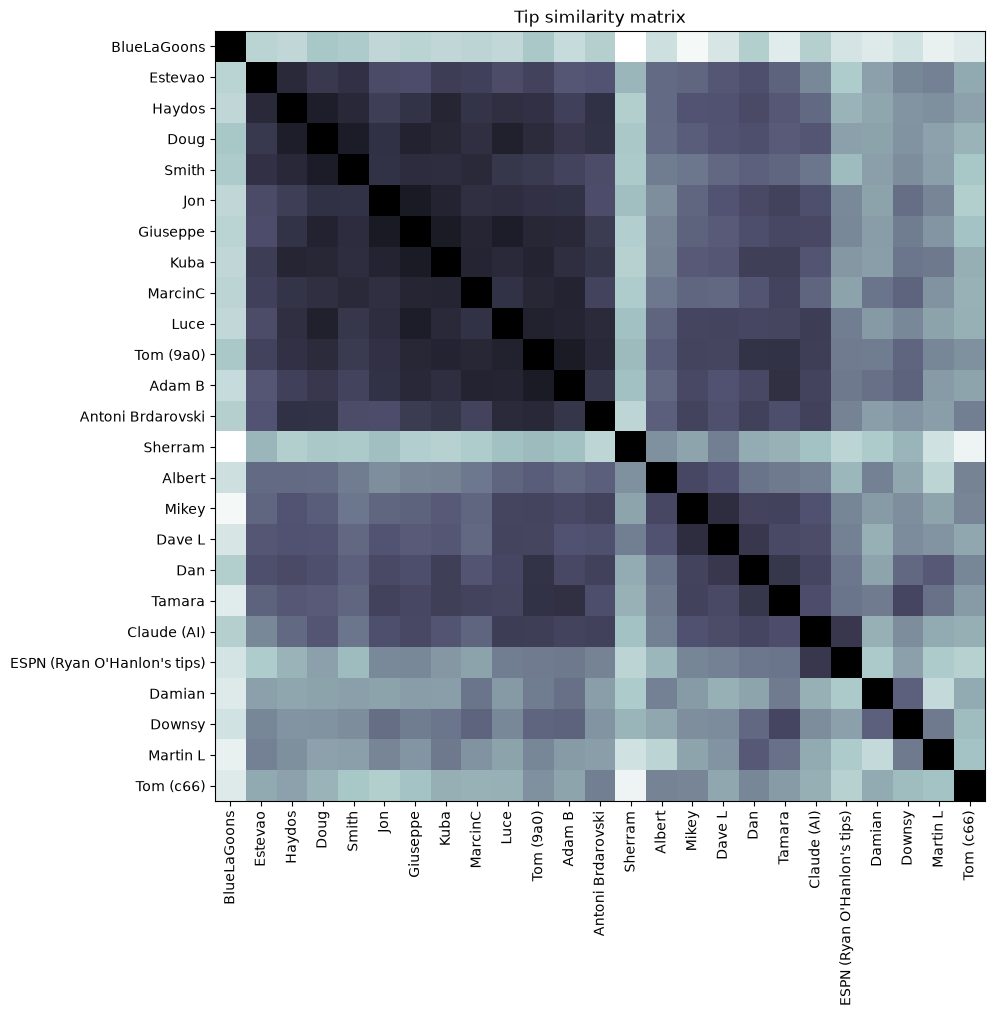

In [7]:
linked_first = linkage(transformed, method="ward")
linked_optimal = optimal_leaf_ordering(linked_first, transformed)
ideal_ordering = transformed.index[leaves_list(linked_optimal)]

plt.figure(figsize=(12, 6))
dendrogram(linked_optimal, labels=transformed.index, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering on World Cup PCA Components")
plt.ylabel("Dissimilarity")
plt.tight_layout()
plt.show()

reordered_transformed = transformed.loc[ideal_ordering]
similarity_matrix = pairwise_distances(reordered_transformed)

fig, ax = plt.subplots(figsize=(10, 10))
cax = ax.imshow(similarity_matrix, cmap="bone")
ax.set_xticks(np.arange(len(ideal_ordering)))
ax.set_yticks(np.arange(len(ideal_ordering)))
ax.set_xticklabels(ideal_ordering, rotation=90, fontsize=10)
ax.set_yticklabels(ideal_ordering, fontsize=10)
ax.set_title("Tip similarity matrix")

plt.show()